# 02 - EDA Clientes Y Churn

## Hipotesis iniciales

1. El churn acumulado no se reparte de forma homogenea entre segmentos de cliente.
2. El tipo de plan, el tipo de zona y el dispositivo pueden capturar diferencias de precio, cobertura, uso y fidelizacion.
3. Los clientes con menor antiguedad deberian presentar mayor riesgo, porque todavia no han consolidado relacion con la compania.
4. Variables de valor y vinculacion, como numero de lineas, ingreso estimado y descuento, pueden separar perfiles mas o menos propensos a abandonar.
5. Los flags de calidad del dato pueden revelar segmentos con informacion incompleta o corregida, y conviene comprobar si tambien se asocian a churn.

## Que se va a contrastar

- Distribucion de clientes con churn observado.
- Diferencias por plan, zona, antiguedad y variables numericas de perfil.
- Relacion entre flags de calidad del dato y churn.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

clientes = pd.read_csv(PROCESSED / 'clientes_clean.csv')
churn = pd.read_csv(PROCESSED / 'churn_target_clean.csv', parse_dates=['fecha'])
ever = churn.groupby('cliente_id', as_index=False).agg(ever_churn=('churn', 'max'))
df = clientes.merge(ever, on='cliente_id', how='left')
df['ever_churn'] = df['ever_churn'].fillna(0).astype(int)


In [3]:
display(df.head())
display(df['ever_churn'].value_counts(normalize=True).rename('pct_clientes').mul(100).round(2))


,cliente_id,zona_id,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,...,poblacion_zona,edad_was_missing,ingreso_estimado_was_missing,antiguedad_meses_was_missing,antiguedad_meses_was_invalid,sexo_was_missing,estado_civil_was_missing,tipo_plan_was_missing,tipo_dispositivo_was_missing,ever_churn
0,C000001,Z26,18.000,M,Soltero/a,2,Prepago,Gama alta,"4,335.000",72.000,...,"107,159.000",0,0,0,0,0,0,0,0,0
1,C000002,Z15,54.000,M,Casado/a,2,Premium,Gama media,"4,609.000",35.000,...,"62,939.000",0,0,0,0,0,0,0,0,0
2,C000003,Z27,54.000,M,Casado/a,3,Prepago,Gama baja,"1,836.000",11.000,...,"42,704.000",0,0,0,0,0,0,0,0,1
3,C000004,Z22,34.000,M,Soltero/a,1,Prepago,Gama media,"2,318.000",13.000,...,"53,534.000",0,0,0,0,0,0,0,0,0
4,C000005,Z04,46.000,F,Soltero/a,2,Contrato,Gama media,"2,184.000",21.000,...,"55,457.000",0,0,0,0,0,0,0,0,0


ever_churn
0   80.000
1   20.000
Name: pct_clientes, dtype: float64

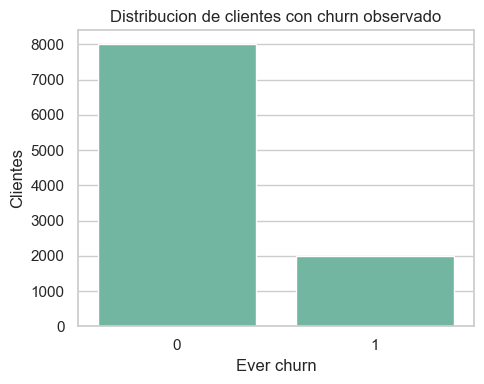

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='ever_churn')
plt.title('Distribucion de clientes con churn observado')
plt.xlabel('Ever churn')
plt.ylabel('Clientes')
plt.tight_layout()
plt.show()


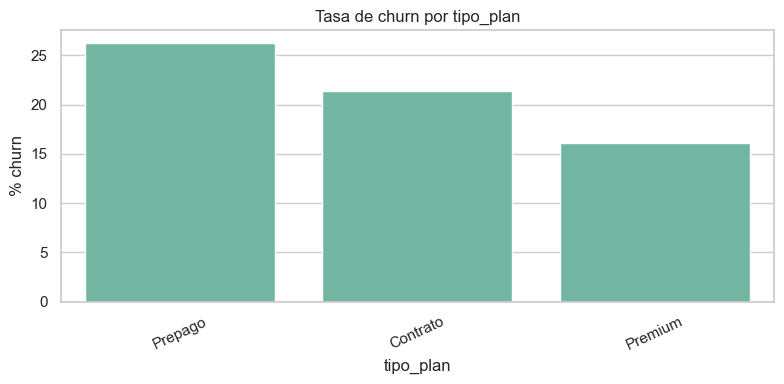

,tipo_plan,n,churn_rate
0,Prepago,2680,26.231
1,Contrato,2258,21.435
2,Premium,5062,16.061


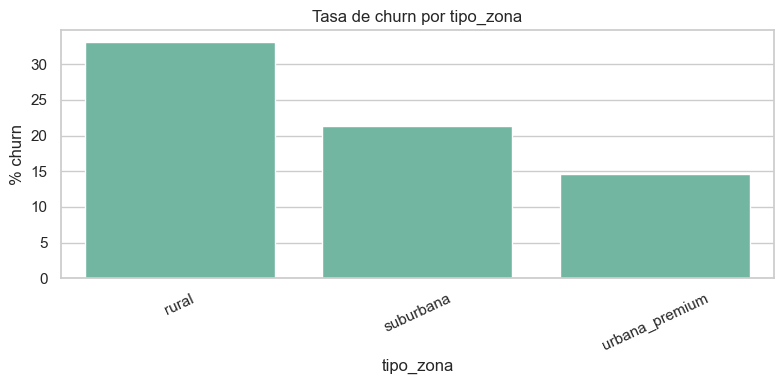

,tipo_zona,n,churn_rate
0,rural,1473,33.062
1,suburbana,3956,21.335
2,urbana_premium,4571,14.636


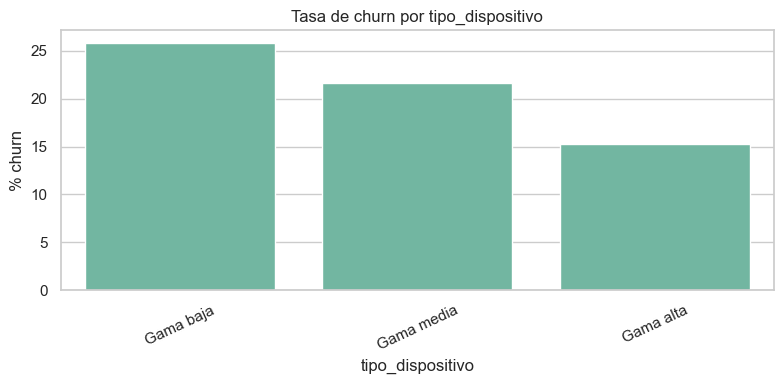

,tipo_dispositivo,n,churn_rate
0,Gama baja,864,25.810
1,Gama media,6060,21.568
2,Gama alta,3076,15.280


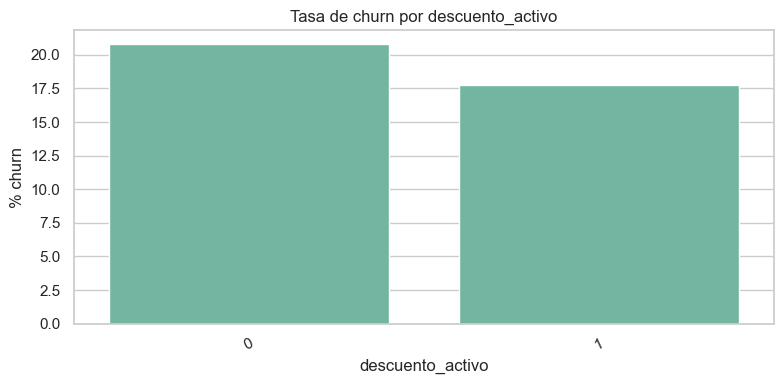

,descuento_activo,n,churn_rate
0,0,7450,20.779
1,1,2550,17.725


In [5]:
def churn_rate(data, col):
    return (data.groupby(col)['ever_churn']
            .agg(n='count', churn_rate='mean')
            .assign(churn_rate=lambda x: x['churn_rate'] * 100)
            .sort_values('churn_rate', ascending=False))

for col in ['tipo_plan', 'tipo_zona', 'tipo_dispositivo', 'descuento_activo']:
    rates = churn_rate(df, col).reset_index()
    plt.figure(figsize=(8, 4))
    sns.barplot(data=rates, x=col, y='churn_rate')
    plt.title(f'Tasa de churn por {col}')
    plt.ylabel('% churn')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
    display(rates)


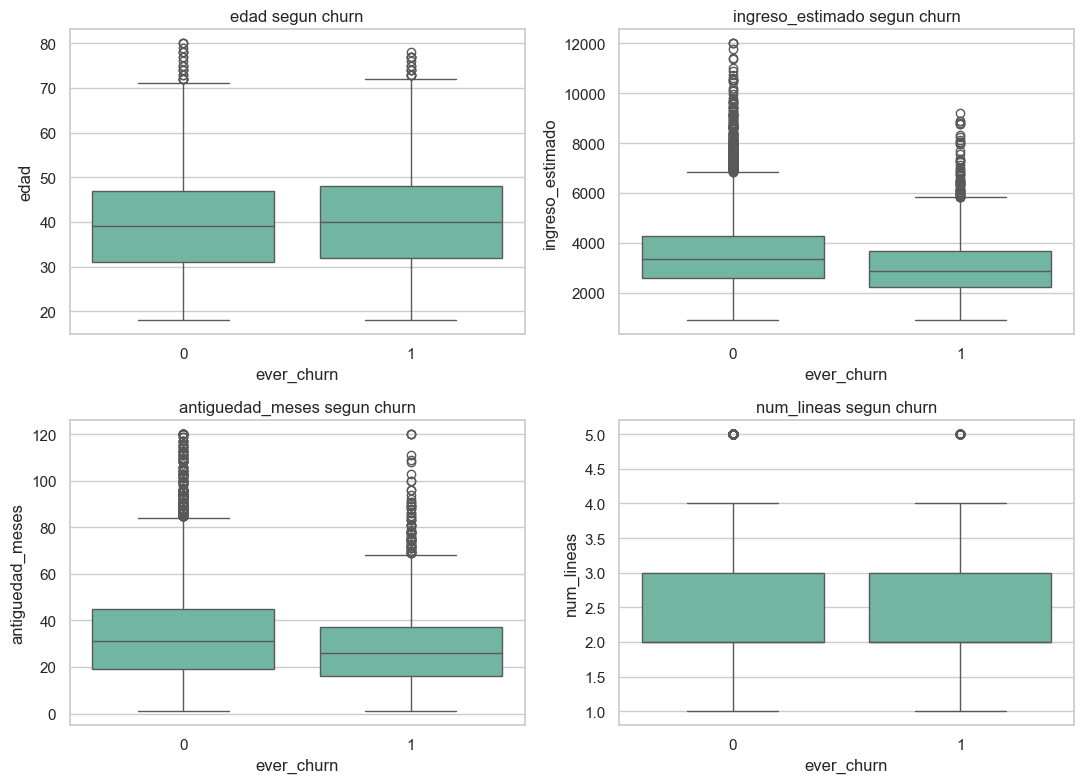

In [6]:
num_cols = ['edad', 'ingreso_estimado', 'antiguedad_meses', 'num_lineas']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='ever_churn', y=col, ax=ax)
    ax.set_title(f'{col} segun churn')
plt.tight_layout()
plt.show()


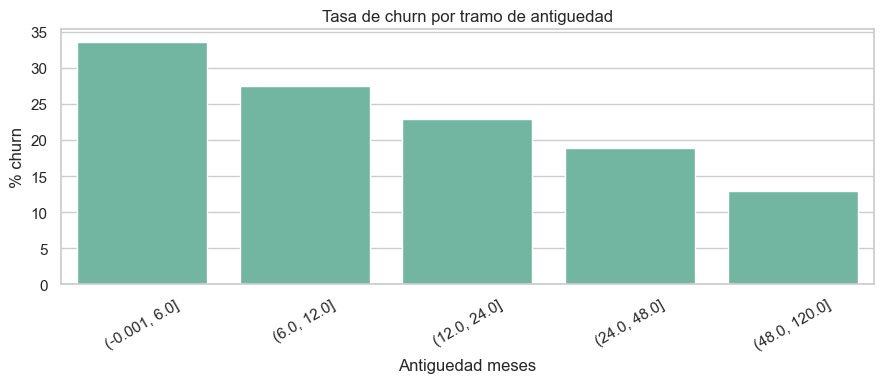

In [7]:
df['antiguedad_bucket'] = pd.cut(df['antiguedad_meses'], bins=[0, 6, 12, 24, 48, 120], include_lowest=True)
rates = churn_rate(df, 'antiguedad_bucket').reset_index()
plt.figure(figsize=(9, 4))
sns.barplot(data=rates, x='antiguedad_bucket', y='churn_rate')
plt.title('Tasa de churn por tramo de antiguedad')
plt.ylabel('% churn')
plt.xlabel('Antiguedad meses')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [8]:
flag_cols = [c for c in df.columns if c.endswith('_was_missing') or c.endswith('_was_invalid')]
flag_rates = []
for col in flag_cols:
    if df[col].nunique() > 1:
        flag_rates.append({'flag': col, 'churn_rate': df.loc[df[col] == 1, 'ever_churn'].mean() * 100, 'n': int((df[col] == 1).sum())})
display(pd.DataFrame(flag_rates).sort_values('churn_rate', ascending=False))


,flag,churn_rate,n
1,edad_was_missing,22.667,300
5,sexo_was_missing,20.000,45
3,antiguedad_meses_was_missing,19.667,300
2,ingreso_estimado_was_missing,18.667,300
0,zona_id_was_invalid,18.000,150
4,antiguedad_meses_was_invalid,16.552,145
6,estado_civil_was_missing,15.584,77


## Conclusiones finales

- El churn observado a nivel cliente esta concentrado en una minoria relevante: aproximadamente el 20% de clientes tuvo churn alguna vez, frente al 80% sin churn.
- El tipo de plan muestra diferencias claras: `Prepago` presenta mayor churn acumulado, alrededor del 26.2%, mientras `Premium` baja a cerca del 16.1%.
- La antiguedad es una variable clave para segmentacion: los tramos de menor permanencia deben revisarse especialmente porque pueden concentrar abandono temprano.
- Las variables de perfil no deben interpretarse como causalidad aislada, pero si ayudan a definir segmentos comerciales para el modelo y para acciones de retencion.
- Los flags de calidad del dato no invalidan el analisis; pueden conservarse como senales candidatas porque algunos muestran tasas de churn distintas a la media.

## Decisiones para feature engineering

- Incluir variables estaticas de cliente en todas las filas cliente-mes.
- Mantener `antiguedad_meses` y crear tramos de antiguedad.
- Codificar plan, zona, dispositivo y variables demograficas de forma consistente.
- Mantener flags de imputacion/correccion como features candidatas.
- No usar este EDA como target final: el modelado debe trabajar con churn temporal `t+1`.
